# Удержание пользователей Яндекс Афиши 

## Цели и задачи проекта 

#### Цели проекта:
На основе исследовательского анализа данных сформировать рекомендации для удержания пользователей Яндекс Афиши. 
#### Задачи проекта:
1. Загрузка данных и знакомство с ними
2. Предобработка данных. Предобработка состоит из следующих пунктов:
    - Приведение данных о выручке к единой валюте - российскому рублю 
    - Анализ и обработка пропущенных значений
    - Приведение полей датафрейма к корректным типам данных
    - Нормализация данных. Анализ категоральных данных
    - Проверка данных на наличие выбросов
    - Промежуточный вывод
3. Создание профиля пользователя. 
    - Построение профиля пользователя
    - Проверка репрезентативности 
    - Промежуточный вывод 
4. Исследовательский анализ данных. Анализ состоит из следующих пунктов: 
    - Исследование признаков первого заказа и их связи с возвращением на платформу
    - Исследование поведения пользователей через показатели выручки и состава заказа
    - Исследование временных характеристик первого заказа и их влияния на повторные покупки
    - Корреляционный анализ количества покупок и признаков пользователя
    - Промежуточный вывод
5. Итоговый вывод и рекомендации 

## Описание данных

Данные представляют собой историю покупок пользователей на Яндекс Афише. Они используются для анализа поведения клиентов и выявления факторов, влияющих на повторные заказы и удержание.

Каждая строка — это один заказ пользователя с ключевыми характеристиками:
- user_id — идентификатор пользователя
- order_id — идентификатор заказа
- order_dt / order_ts — дата и время покупки
- device_type_canonical — устройство, с которого оформлен заказ (mobile, desktop)
- currency_code, revenue — валюта и сумма выручки
- tickets_count — число купленных билетов
- days_since_prev — число дней с предыдущей покупки
- event_id — идентификатор мероприятия
- event_type_main — тип события (концерт, театр и т.п.)
- service_name — билетный оператор
- region_name, city_name — регион и город проведения мероприятия


## 1. Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
from sqlalchemy import create_engine 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import phik as ph
from dotenv import load_dotenv
import os


In [2]:
load_dotenv()

True

In [3]:
DB_USER = os.getenv("DB_USER")
DB_PWD = os.getenv("DB_PWD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

In [4]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    DB_USER,
    DB_PWD,
    DB_HOST,
    DB_PORT,
    DB_NAME,
)

In [5]:
engine = create_engine(connection_string)

In [6]:
query = '''
WITH set_config_precode AS (
    SELECT set_config('synchronize_seqscans', 'off', true)
)

SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk AS order_dt,
    created_ts_msk AS order_ts,
    currency_code,
    revenue,
    tickets_count,
    (p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (
        PARTITION BY user_id
        ORDER BY created_dt_msk
    )) AS days_since_prev,
    event_id,
    event_name_code AS event_name,
    event_type_main,
    service_name,
    region_name,
    city_name
FROM afisha.purchases p
LEFT JOIN afisha.events e USING (event_id)
LEFT JOIN afisha.city c USING (city_id)
LEFT JOIN afisha.regions r USING (region_id)
WHERE p.device_type_canonical IN ('mobile', 'desktop') AND event_type_main NOT IN ('фильм')
ORDER BY user_id;
''' 

In [7]:
df = pd.read_sql_query(query, con=engine)

In [8]:
df.to_parquet("data/processed/data.parquet")

In [9]:
df_copy = df.copy()

In [10]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

### Промежуточный вывод
- Данные выгружены корректо
- Объем данных: 290611 строк
- Все названия полей в формате snake 
- Пропуски есть только в поле days_since_prev
- Типы данных у всех полей верные, но численные поля можно привести к более подходящим по памяти. Например, поле tickets_count не требует типа int64. 
- Пропуски есть только в поле days_since_prev. они связаны с тем, что некоторые пользователи делали только 1 заказ.

## 2. Предобработка данных

In [12]:
kzt_rub_rate = pd.read_csv('data/raw/final_tickets_tenge_df.csv')

In [13]:
kzt_rub_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [14]:
kzt_rub_rate['data'] = pd.to_datetime(kzt_rub_rate['data'])
kzt_rub_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 11.3+ KB


теперь все типы данных в датафрейме kzt_rub_rate верные 

In [15]:
kzt_rub_rate.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [16]:
columns = kzt_rub_rate.columns

In [17]:
# добавляем информацию о курсах валют в исходный df
df = df.merge(
    kzt_rub_rate,
    left_on="order_dt",
    right_on="data",
    how="left"
)

In [18]:
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
df = df.drop(columns=columns)
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


Успешно создали поле revenue_rub с выручкой в единой валюте - рублях. 

### Анализ и обработка пропущенных значений

In [19]:
# посчитаем число и долю пропусков в данных
missed = pd.DataFrame({'count': df.isna().sum(), 'share': round(df.isna().sum() / len(df), 3)}).sort_values('share', ascending = False)
missed

,count,share
days_since_prev,21933,0.075
user_id,0,0.000
device_type_canonical,0,0.000
order_id,0,0.000
order_dt,0,0.000
order_ts,0,0.000
currency_code,0,0.000
revenue,0,0.000
tickets_count,0,0.000
event_id,0,0.000


Как уже было сказано, пропуски есть только в поле days_since_prev, и они у тех пользователей, которые сделали 1 заказа. пропуски составляют менее 8%. это естественные проупски. если удалить их, то мы удалим всех пользователей, совершивших 1 зазказ. так что пропуски оставим. 

### Приведение полей датафрейма к корректным типам данных

In [20]:
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='float')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Теперь все поля имеют корректный тип данных. 

### Нормализация данных. Анализ категоральных данных. Удаление пропусков

In [21]:
# Анализ категориальных значений
for column in ['device_type_canonical', 'event_type_main', 'service_name']:
    print(f"\nColumn: {column}")
    print("Unique values:", df[column].unique())
    print("Missing values count:", df[column].isna().sum())
    print("Value counts:")
    print(df[column].value_counts(dropna=False), "\n")


Column: device_type_canonical
Unique values: ['mobile' 'desktop']
Missing values count: 0
Value counts:
device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64 


Column: event_type_main
Unique values: ['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки']
Missing values count: 0
Value counts:
event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64 


Column: service_name
Unique values: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Ц

заметим, что у 9 билетных операторов менее 100 заказов. у 4 из них меньше 25:  тех билет (22),  лимоны(8),  зе бест! (5),  билеты в интернете   (4). это может пригодиться при дальнейшем анализе                  

In [22]:
df[['device_type_canonical', 'currency_code', 'event_type_main', 'service_name', 
'region_name', 'city_name']] = df[[
'device_type_canonical', 'currency_code', 'event_type_main', 'service_name', 'region_name', 
'city_name']].apply(lambda x: x.str.lower())

In [23]:
print(len(df))
df = df.drop_duplicates()
len(df)

290611


290611

In [24]:
df['order_id'].duplicated().sum()

np.int64(0)

Была получена информация категоральных признаках. 
- В поле device_type_canonical всего две категории: 'mobile' и 'desktop'. Данные по этим категориям распределены неравновмерно: большая часть заказов совершена через мобильный телефон.
- В поле event_type_main есть категория 'другое', которая занимает значительную часть данных и означет отсутсвие информации о типе ивента. 
- Категоральыне данные приведены к нижнему регистру
- Явных дубликатов в данных не оказалось  

### Проверка данных на наличие выбросов

In [25]:
# посмотрим на значения выручки 

df['revenue_rub'].describe()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

В данных о выручке есть отрицательные значения. Видимо, это возвраты. Посмтрим, какая доля заказов имеет отрицательную выручку. 

In [26]:
print((df['revenue_rub'] < 0).sum())
round((df['revenue_rub'] < 0).sum() / len(df), 4)

381


np.float64(0.0013)

Отрицательных значений выручки в датафрейме менее одной пятой доли процента. Удалим такие данные из анализа, чтобы не искажать стаитистики. 

In [27]:
df = df[df['revenue_rub'] >= 0]

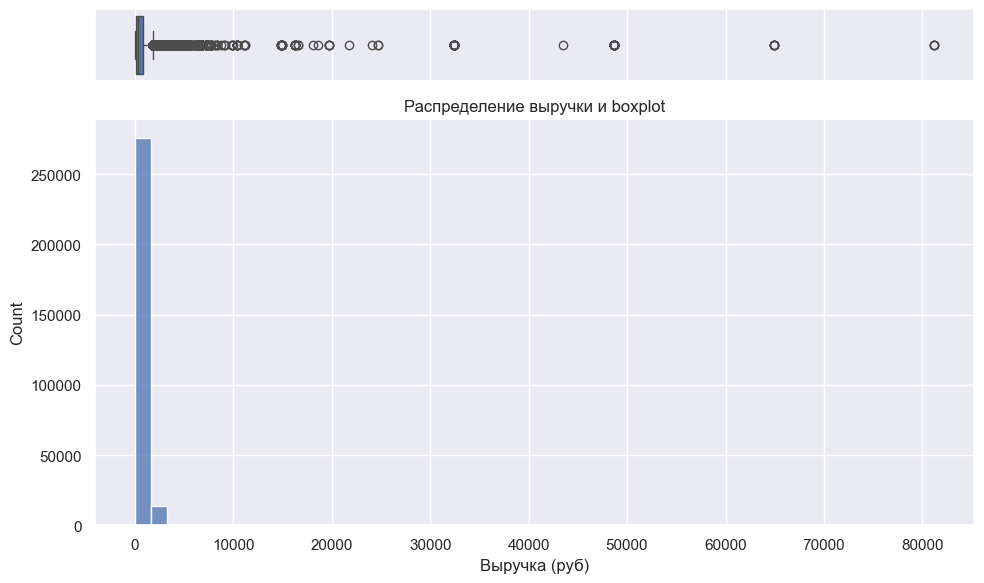

In [28]:
sns.set_theme(style="darkgrid")

# создаём 2 оси: верх — boxplot, низ — гистограмма
f, (ax_box, ax_hist) = plt.subplots(
    2,
    sharex=True,
    gridspec_kw={"height_ratios": (.15, .85)},
    figsize=(10, 6))

sns.boxplot(
    x=df["revenue_rub"],
    orient="h",
    ax=ax_box)

sns.histplot(
    data=df,
    x="revenue_rub",
    ax=ax_hist,
    bins=50)

ax_box.set(xlabel='')


ax_hist.set_xlabel("Выручка (руб)")
ax_hist.set_title("Распределение выручки и boxplot")

plt.tight_layout()
plt.show()

график показвает, что в данных есть большое количество правосторонних выбросов. отфильтруем данные: удалим те, что находятся правее 99% процентиля. так полученные статистики (например, среднее) будет менее смещено.  

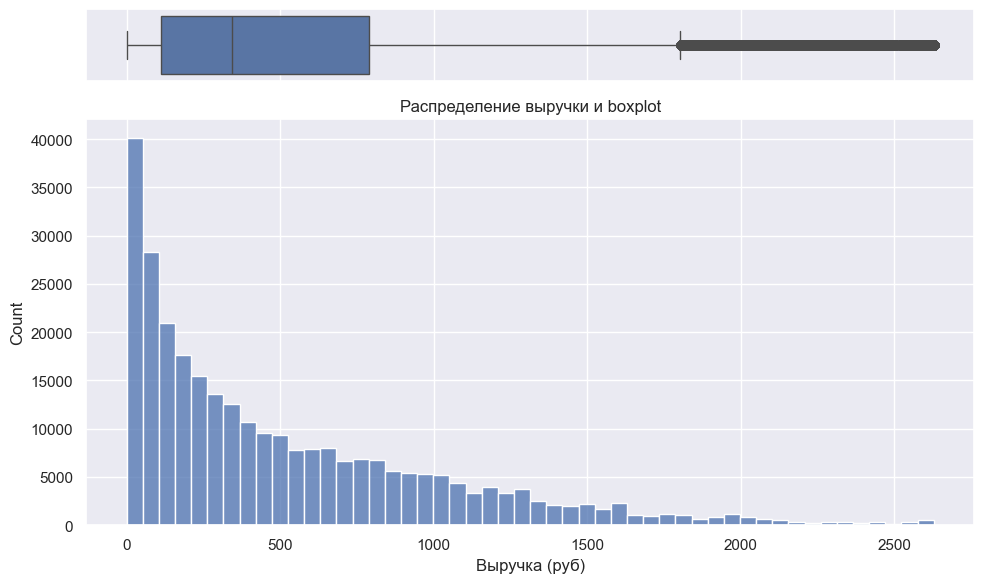

In [29]:
p99 = df['revenue_rub'].quantile(0.99)
df = df[df['revenue_rub'] <= p99]

sns.set_theme(style="darkgrid")

# создаём 2 оси: верх — boxplot, низ — гистограмма
f, (ax_box, ax_hist) = plt.subplots(
    2,
    sharex=True,
    gridspec_kw={"height_ratios": (.15, .85)},
    figsize=(10, 6))

sns.boxplot(
    x=df["revenue_rub"],
    orient="h",
    ax=ax_box)

sns.histplot(
    data=df,
    x="revenue_rub",
    ax=ax_hist,
    bins=50)

ax_box.set(xlabel='')


ax_hist.set_xlabel("Выручка (руб)")
ax_hist.set_title("Распределение выручки и boxplot")

plt.tight_layout()
plt.show()

в данных все еще есть выбросы. но теперь они не экстремальные. 

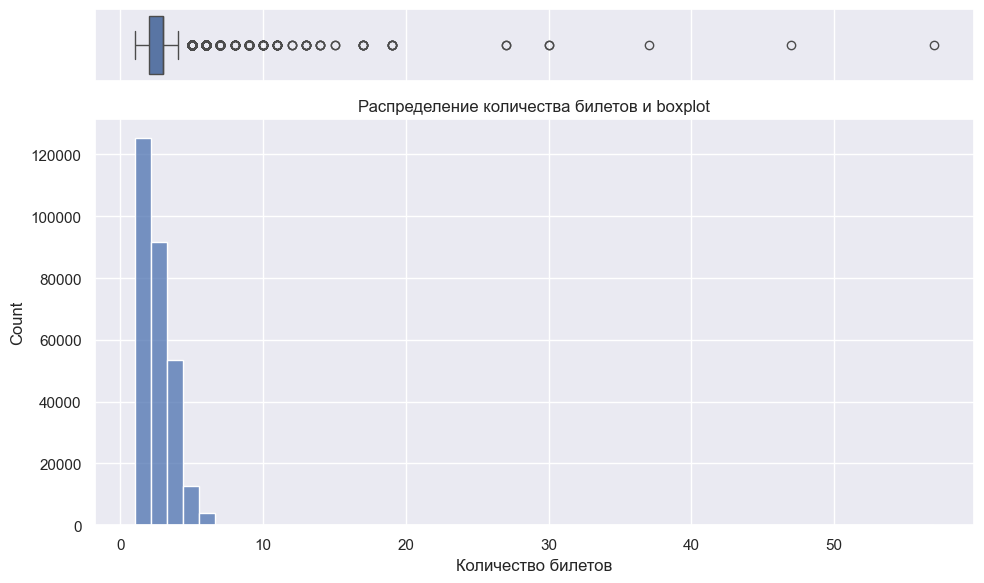

In [30]:
sns.set_theme(style="darkgrid")

# создаём 2 оси: верх — boxplot, низ — гистограмма
f, (ax_box, ax_hist) = plt.subplots(
    2,
    sharex=True,
    gridspec_kw={"height_ratios": (.15, .85)},
    figsize=(10, 6))

sns.boxplot(
    x=df["tickets_count"],
    orient="h",
    ax=ax_box)

sns.histplot(
    data=df,
    x="tickets_count",
    ax=ax_hist,
    bins=50)

ax_box.set(xlabel='')


ax_hist.set_xlabel("Количество билетов")
ax_hist.set_title("Распределение количества билетов и boxplot")

plt.tight_layout()
plt.show()

видимо, в данных есть грапповые зазазы (больше 10 билетов). по той же логике удалим данные правее 99 процентиля. 

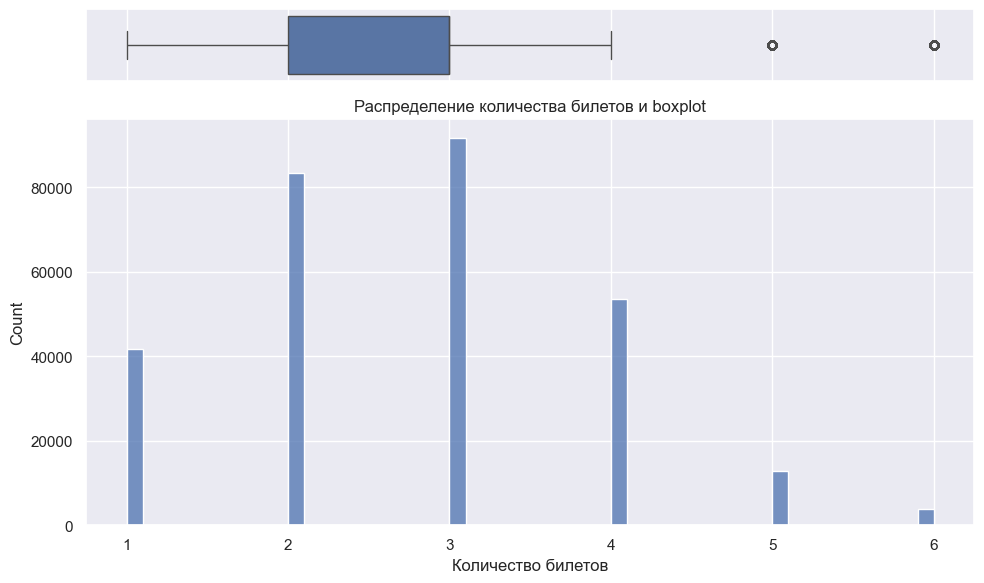

In [31]:
# отфильтруем данные по 99 процентилю

p99 = df['tickets_count'].quantile(0.99)
df = df[df['tickets_count'] <= p99]

sns.set_theme(style="darkgrid")

# создаём 2 оси: верх — boxplot, низ — гистограмма
f, (ax_box, ax_hist) = plt.subplots(
    2,
    sharex=True,
    gridspec_kw={"height_ratios": (.15, .85)},
    figsize=(10, 6))

sns.boxplot(
    x=df["tickets_count"],
    orient="h",
    ax=ax_box)

sns.histplot(
    data=df,
    x="tickets_count",
    ax=ax_hist,
    bins=50)

ax_box.set(xlabel='')


ax_hist.set_xlabel("Количество билетов")
ax_hist.set_title("Распределение количества билетов и boxplot")

plt.tight_layout()
plt.show()

### Промежуточный вывод
- создано новое поле revenue_rub, содержащее информацию о выручке в рублях 
- произведен нанализ пропусков: пропуски оказались только в поле days_since_prev. они составляют менее 8% от общего числа данных. пропуски обусловлены естетсвенными причинами: они возникли у тех пользователей, которые совершили только 1 заказ на платформе
- данные приведены к корректным типам 
- категоральные данные нормализованы. в поле event_type_main обнаружена категория 'другое', которая говорит об отсутсвии информации и типе ивента
- в поле revenue_rub найдены отрицательные значения. было принято решение их удалить. 
- поля revenue_rub и tickets_count очищены от выбросов. 



По итогу предобратки данные скоратились на 3386 строк, или на 1% 

In [32]:
print(len(df_copy) - len(df))
round((len(df_copy) - len(df))/len(df_copy), 4)


3386


0.0117

In [33]:
df_clean_copy = df.copy()

## 3. Создание профиля пользователя. 

### Построение профиля пользователя

Для выявления причин, по которым пользователи остаются на сервисе, создадим профиль. Включим в него следующие поля, которые потенциально влияют на удержание: 
- дата первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёр, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия
- общее количество заказов
- средняя выручка с одного заказа в рублях
- среднее количество билетов в заказе
- среднее время между заказами
— совершил ли пользователь 2 и более заказа;
- совершил ли пользователь 5 и более заказов.

In [34]:
df = df.sort_values(['user_id', 'order_dt'])

# считаем разницу между заказами, чтобы посчитать среднее время 
# group_by + diff работает как окно + лоаговый оператор в sql 
df['days_diff'] = df.groupby('user_id')['order_dt'].diff().dt.days

In [35]:
# создаем агрегированный профиль
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'min'),
    last_order_dt=('order_dt', 'max'),
    first_device=('device_type_canonical', lambda x: x.iloc[0]),
    first_region=('region_name', lambda x: x.iloc[0]),
    first_partner=('service_name', lambda x: x.iloc[0]),
    first_event_genre=('event_type_main', lambda x: x.iloc[0]),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between=('days_diff', 'mean')
).reset_index()

# добавляем бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

user_profile.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_partner,first_event_genre,total_orders,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


In [36]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21831 entries, 0 to 21830
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            21831 non-null  object        
 1   first_order_dt     21831 non-null  datetime64[ns]
 2   last_order_dt      21831 non-null  datetime64[ns]
 3   first_device       21831 non-null  object        
 4   first_region       21831 non-null  object        
 5   first_partner      21831 non-null  object        
 6   first_event_genre  21831 non-null  object        
 7   total_orders       21831 non-null  int64         
 8   avg_revenue_rub    21831 non-null  float64       
 9   avg_tickets        21831 non-null  float64       
 10  avg_days_between   13469 non-null  float64       
 11  is_two             21831 non-null  int64         
 12  is_five            21831 non-null  int64         
dtypes: datetime64[ns](2), float64(3), int64(3), object(5)
memory 

In [37]:
user_profile_copy = user_profile.copy() 

### Проверка репрезентативности

Репрезентативность - важное свойство выборки для анализа поведения клиентов. Выбросы в данных могут сильно искажать статистики, в точ числе статистики для проверки гипотез. Проверим поля total_orders, avg_tickets и avg_days_between на выбросы. Также изучем агрегированные показатели профиля пльзователя. 

In [38]:
# oбщее число пользователей
total_users = user_profile['user_id'].nunique()

# cредняя выручка с одного заказа
avg_revenue_per_order = round(user_profile['avg_revenue_rub'].mean())

# доля пользователей, совершивших 2+ заказа
share_two = round((user_profile['is_two'].mean()), 2)  

# доля пользователей, совершивших 5+ заказов
share_five = round((user_profile['is_five'].mean()), 2)

print('Общее число пользователей: ', total_users)
print('Средняя выручка с одного заказа: ', avg_revenue_per_order)
print('Доля пользователей, совершивших 2+ заказа: ', share_two)
print('Доля пользователей, совершивших 5+ заказов: ', share_five)

Общее число пользователей:  21831
Средняя выручка с одного заказа:  545
Доля пользователей, совершивших 2+ заказа:  0.62
Доля пользователей, совершивших 5+ заказов:  0.29


In [39]:
user_profile[['total_orders', 'avg_tickets', 'avg_days_between']].describe()

,total_orders,avg_tickets,avg_days_between
count,21831.000000,21831.000000,13469.000000
mean,13.156750,2.740095,15.896775
std,121.484319,0.902688,22.291375
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.083333
75%,5.000000,3.071429,20.500000
max,10155.000000,6.000000,148.000000


в поле total_orders явно есть экстремальные выбросы: максимальное значение составляет  10168, что более чем в 2000 раз превышает превышает значение 75 процентиля. 

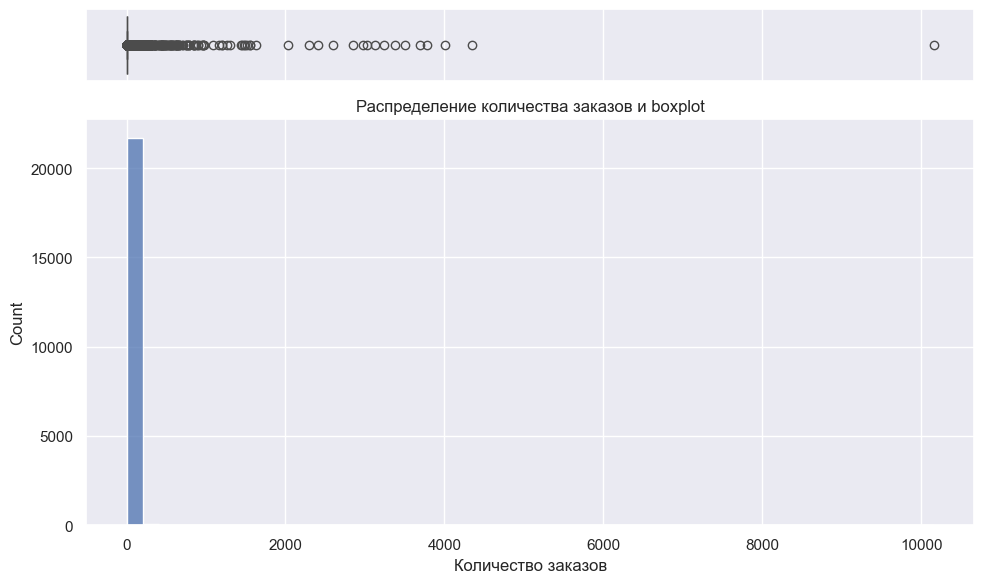

In [40]:
sns.set_theme(style="darkgrid")
# создаём 2 оси: верх — boxplot, низ — гистограмма
f, (ax_box, ax_hist) = plt.subplots(
    2,
    sharex=True,
    gridspec_kw={"height_ratios": (.15, .85)},
    figsize=(10, 6))

sns.boxplot(
    x=user_profile["total_orders"],
    orient="h",
    ax=ax_box)

sns.histplot(
    data=user_profile,
    x="total_orders",
    ax=ax_hist,
    bins=50)

ax_box.set(xlabel='')


ax_hist.set_xlabel("Количество заказов")
ax_hist.set_title("Распределение количества заказов и boxplot")

plt.tight_layout()
plt.show()

при сравнении 95 и 99 процентилей видно, что аномальные значения начинают появляться гораздо раньше, чем самый хвост распределения. Если оставить 99% данных, практически все выбросы сохраняются, что сильно скается на статистиках. выборка не будет репрезентативной. поэтому удалим данные правее 95 процентиля. 

In [41]:
# удалим даннее выше 95 процентиля 

p95 = user_profile['total_orders'].quantile(0.95)
user_profile = user_profile[user_profile['total_orders'] <= p95]

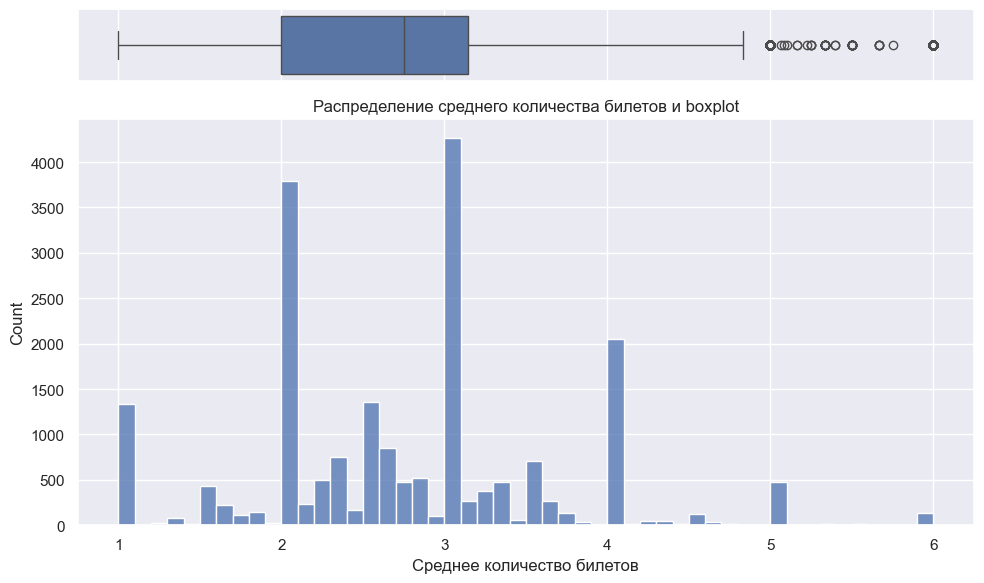

In [42]:
sns.set_theme(style="darkgrid")
# создаём 2 оси: верх — boxplot, низ — гистограмма
f, (ax_box, ax_hist) = plt.subplots(
    2,
    sharex=True,
    gridspec_kw={"height_ratios": (.15, .85)},
    figsize=(10, 6))

sns.boxplot(
    x=user_profile["avg_tickets"],
    orient="h",
    ax=ax_box)

sns.histplot(
    data=user_profile,
    x="avg_tickets",
    ax=ax_hist,
    bins=50)

ax_box.set(xlabel='')


ax_hist.set_xlabel("Среднее количество билетов")
ax_hist.set_title("Распределение среднего количества билетов и boxplot")

plt.tight_layout()
plt.show()

выбросов немного. оставим 99% данных 

In [43]:
# удалим даннее выше 99 процентиля 

p99 = user_profile['avg_tickets'].quantile(0.99)
user_profile = user_profile[user_profile['avg_tickets'] <= p99]

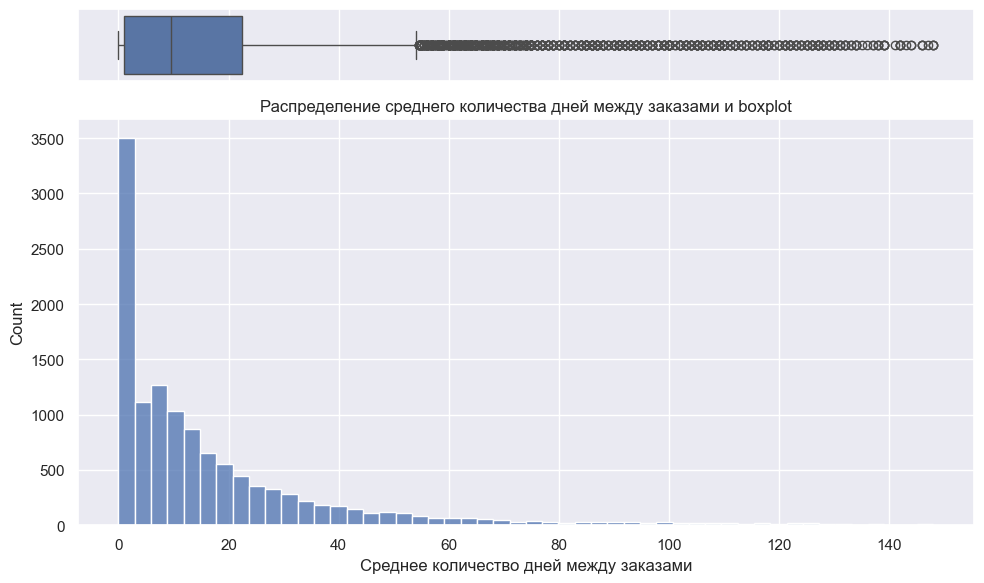

In [44]:
sns.set_theme(style="darkgrid")
# создаём 2 оси: верх — boxplot, низ — гистограмма
f, (ax_box, ax_hist) = plt.subplots(
    2,
    sharex=True,
    gridspec_kw={"height_ratios": (.15, .85)},
    figsize=(10, 6))

sns.boxplot(
    x=user_profile["avg_days_between"],
    orient="h",
    ax=ax_box)

sns.histplot(
    data=user_profile,
    x="avg_days_between",
    ax=ax_hist,
    bins=50)

ax_box.set(xlabel='')


ax_hist.set_xlabel("Среднее количество дней между заказами")
ax_hist.set_title("Распределение среднего количества дней между заказами и boxplot")

plt.tight_layout()
plt.show()

опять много выбросов. 

In [45]:
# удалим даннее выше 95 процентиля 

user_profile = user_profile[(user_profile['avg_days_between'] <= p95) | (user_profile['avg_days_between'].isna())]

In [46]:
# обновленные ститистики по датасету 

user_profile[['total_orders', 'avg_tickets', 'avg_days_between']].describe()

,total_orders,avg_tickets,avg_days_between
count,18501.000000,18501.000000,10264.000000
mean,4.216907,2.707916,8.885682
std,5.379312,0.893524,8.617690
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,0.000000
50%,2.000000,2.750000,7.000000
75%,5.000000,3.071429,14.500000
max,31.000000,5.000000,31.000000


In [47]:
# посмотрим также, как изменилась средняя выручка после очистки данных 
avg_revenue_per_order = round(user_profile['avg_revenue_rub'].mean())
print('Средняя выручка с одного заказа: ', avg_revenue_per_order)

Средняя выручка с одного заказа:  543


средняя выручка с одного заказа практически не изменилась после обработки. 

In [48]:
print(len(user_profile_copy) - len(user_profile))
round((len(user_profile_copy) - len(user_profile))/len(user_profile_copy), 4)

3330


0.1525

In [49]:
user_profile.to_parquet("data/processed/user_profile.parquet")

### Промежуточный вывод

- Был построен профиль пользователя. 
- Построенный датасет был проверен на репрезентативность. В результаты проверки оказалось: 
    1. Поля total_orders и avg_days_between содержали большое число выбросов. Было принято решение удалить значения, превышающе 95 процентиль. 
    2. В поле avg_tickets было выбросов меньше. Принято решение оставить 99% данных. 
- В результате данные уменьшились на 14% 

## 4. Исследовательский анализ данных.

### Исследование признаков первого заказа и их связи с возвращением на платформу

#### Распределение пользователей по признакам

In [50]:
def analyse_segment(df, column):
    """
    - считает количество пользователей
    - считает долю
    - строит диаграмму распределения
    """

    title = column

    seg = (df[column].value_counts(dropna=False).reset_index())


    seg.columns = [column, "users_count"]

    seg["users_count"] = pd.to_numeric(seg["users_count"], errors="coerce")
    seg["users_share"] = seg["users_count"] / len(df)

    seg = seg.sort_values("users_count", ascending=False)

    plt.figure(figsize=(10, 5))
    plt.bar(seg[column].astype(str), seg["users_count"])
    plt.title(f"Распределение пользователей по категории {title}")
    plt.tight_layout()
    plt.show()

    return seg

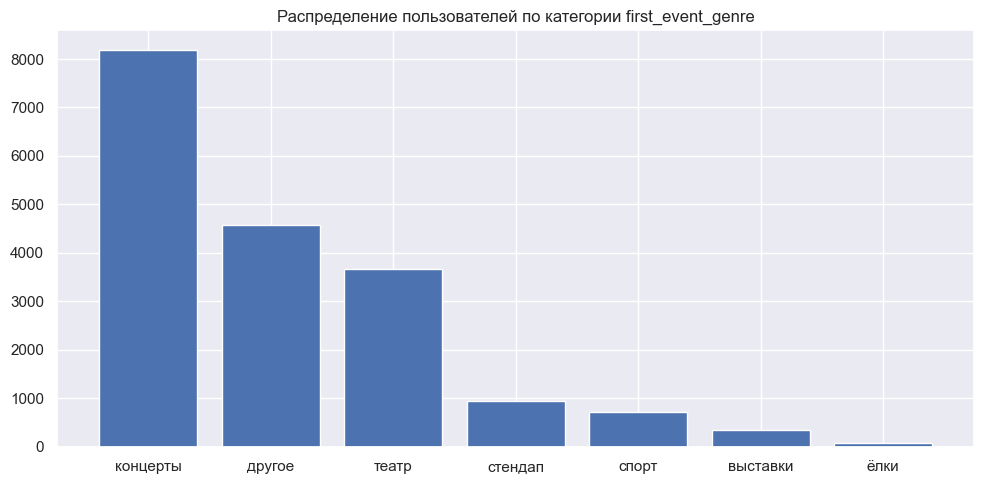

In [51]:
genre_seg = analyse_segment(user_profile, "first_event_genre")

In [52]:
user_profile['first_event_genre'].value_counts(normalize=True).sort_values(ascending=False)

first_event_genre
концерты    0.442192
другое      0.246852
театр       0.197827
стендап     0.051403
спорт       0.038701
выставки    0.018377
ёлки        0.004648
Name: proportion, dtype: float64

Данные по категории первый жанр распределены неравномерно. Есть явные категории-лидеры: концерты, театр и категория 'другое'. Они занимают 90% всех данных. Лидер - концерты. 44% первых заказов приходятся на концерты.  

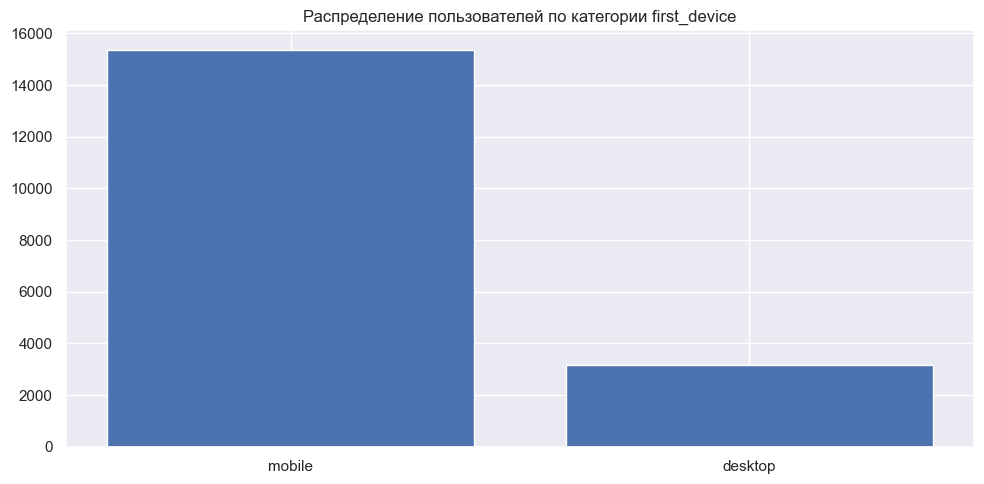

In [53]:
device_seg = analyse_segment(user_profile, "first_device")

In [54]:
user_profile['first_device'].value_counts(normalize=True).sort_values(ascending=False)

first_device
mobile     0.829577
desktop    0.170423
Name: proportion, dtype: float64

82% первых заказов было соврешено через мобильное устройство. 

In [55]:
user_profile['first_region'].value_counts(normalize=True).sort_values(ascending=False).head(10)

first_region
каменевский регион      0.322847
североярская область    0.169721
широковская область     0.056375
озернинский край        0.032755
малиновоярский округ    0.025350
шанырский регион        0.022107
травяная область        0.021566
светополянский округ    0.021404
яблоневская область     0.019837
речиновская область     0.019729
Name: proportion, dtype: float64

/var/folders/yh/ylxxycx91qj6929_sdc0l8_00000gn/T/ipykernel_66898/1963503042.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_regions.values,


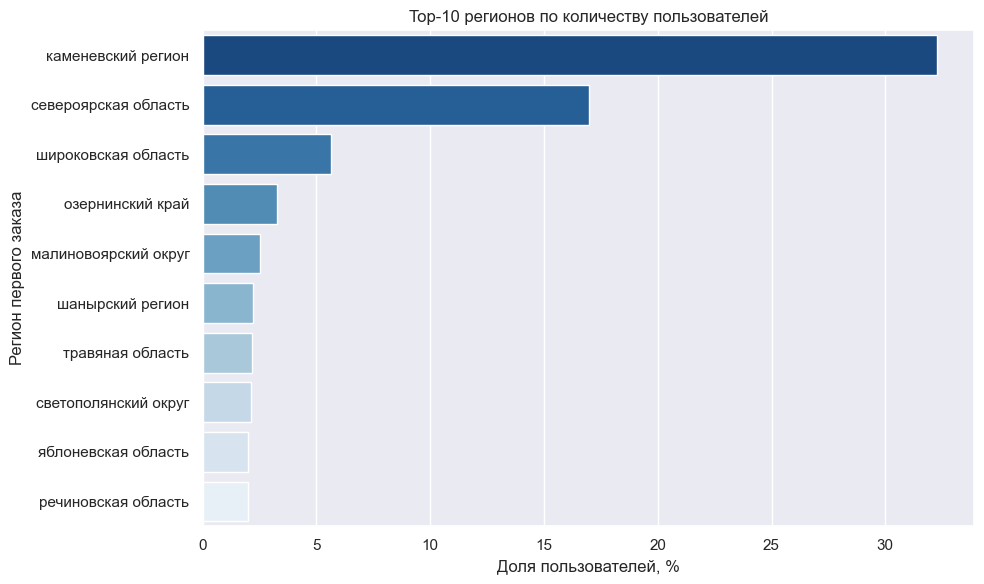

In [56]:
sns.set_theme(style="darkgrid")

# топ-10 регионов
top_regions = (user_profile['first_region']
    .value_counts(normalize=True)
    .sort_values(ascending=False)
    .head(10)
    * 100)

plt.figure(figsize=(10, 6))

sns.barplot(x=top_regions.values,
    y=top_regions.index,
    orient="h",
    palette="Blues_r")

plt.xlabel("Доля пользователей, %")
plt.ylabel("Регион первого заказа")
plt.title("Top-10 регионов по количеству пользователей")

plt.tight_layout()
plt.show()

Лидеры: каменевский регион и североярская область. Их доли 32% и 17% соответственно. Остальные регионы занимают менее 6%.  

In [57]:
user_profile['first_partner'].value_counts(normalize=True).sort_values(ascending=False).head(10)

first_partner
билеты без проблем    0.237230
мой билет             0.138209
лови билет!           0.131344
билеты в руки         0.115994
облачко               0.102157
весь в билетах        0.059402
лучшие билеты         0.055619
прачечная             0.026269
край билетов          0.021134
дом культуры          0.015405
Name: proportion, dtype: float64

/var/folders/yh/ylxxycx91qj6929_sdc0l8_00000gn/T/ipykernel_66898/911516136.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_partners.values,


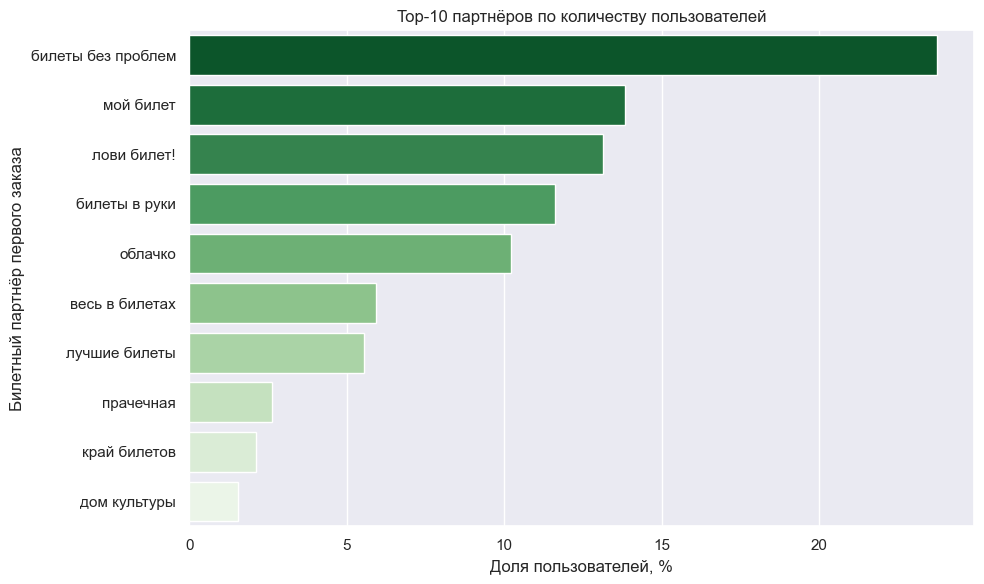

In [58]:
sns.set_theme(style="darkgrid")

# топ-10 партнёров
top_partners = (user_profile['first_partner']
    .value_counts(normalize=True)
    .sort_values(ascending=False)
    .head(10)
    * 100)

plt.figure(figsize=(10, 6))

sns.barplot(x=top_partners.values,
    y=top_partners.index,
    orient="h",
    palette="Greens_r")

plt.xlabel("Доля пользователей, %")
plt.ylabel("Билетный партнёр первого заказа")
plt.title("Top-10 партнёров по количеству пользователей")

plt.tight_layout()
plt.show()

Данные по билетным операторам тоже неравномерные. Лидер - билеты без проблем. Занимет 23% данных. Также выделаются мой билет, лови билет!, билеты в руки  и облачко. Их доля от 10 до 13%. Оставшиеся не превосходят 6%, причем больинство операторов не занимают и 1% 

#### Анализ возвратов пользователей

In [59]:
def segment_return_rate(df, column):
    """
    Строит график долей возвратов по сегменту.
    Сортировка — по убыванию repeat_rate.
    """
    seg = (df.groupby(column).agg(users_count=("user_id", "count"),repeat_rate=("is_two", "mean")).reset_index())

    # выбираем топ-10 по доле возвратов
    seg_top = seg.sort_values("repeat_rate", ascending=False).head(10)

    # строим график
    plt.figure(figsize=(10, 5))
    plt.bar(seg_top[column].astype(str), seg_top["repeat_rate"])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Доля пользователей 2+ заказов")
    plt.title(f"Повторные покупки по категории {column} (топ по возвратам)")
    plt.tight_layout()
    plt.show()

    return seg

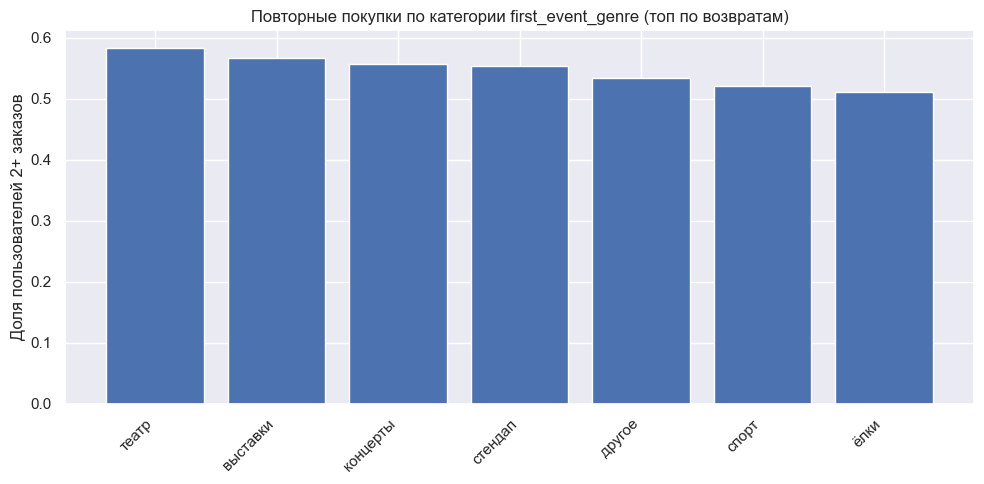

In [60]:
genre_repeat = segment_return_rate(user_profile, "first_event_genre")

пользователи распределены равновмерно по сегментам категории first_event_genre

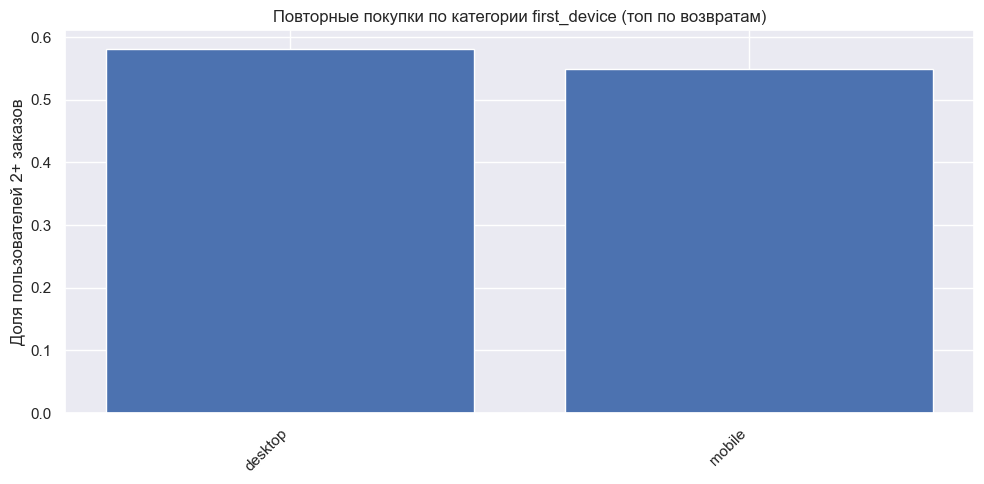

In [61]:
device_repeat = segment_return_rate(user_profile, "first_device")

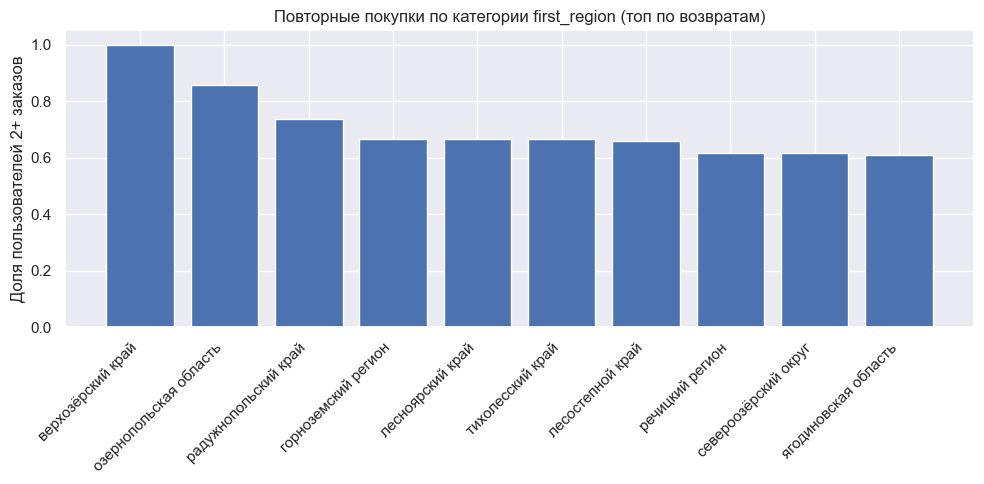

In [62]:
region_repeat = segment_return_rate(user_profile, "first_region")

По графику видно, что различия между регионами значительные: доля повторных покупок колеблется от 60% до 100%. В некоторых регионах (например, верхозёрский край) доля возвратов аномально высокая — близка к 1. Это говорит о том, что регион может быть связан с вероятностью повторного заказа.

Однако важно учитывать, что такие экстремальные значения обычно возникают в малых сегментах. То есть высокая доля возвратов часто обусловлена маленьким количеством пользователей, а не реальным поведением аудитории. Поэтому регионы с очень высокой долей возвратов требуют проверки по размеру сегмента, прежде чем делать продуктовые выводы.

In [63]:
regions_to_check = [
    "верхозёрский край",
    "озернопольская область",
    "радужнопольский край"
]

total_users = len(user_profile)

region_share_overall = (user_profile[user_profile["first_region"].isin(regions_to_check)]["first_region"]
    .value_counts().to_frame("count")
)

region_share_overall["share"] = region_share_overall["count"] / total_users 

region_share_overall

,count,share
first_region,,
озернопольская область,21,0.001135
радужнопольский край,19,0.001027
верхозёрский край,1,0.000054


In [64]:
def segment_return_rate_2(df, column):

    seg = (df.groupby(column).agg(users_count=("user_id", "count"), repeat_rate=("is_two", "mean")).reset_index())

    # сортировка по количеству пользователей
    seg = seg.sort_values("users_count", ascending=False)

    seg_top = seg.head(10)

    # построение графика
    plt.figure(figsize=(10, 5))
    plt.bar(seg_top[column].astype(str), seg_top["repeat_rate"])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Доля пользователей 2+ заказов")
    plt.title(f"Повторные покупки по категории {column}")
    plt.tight_layout()
    plt.show()

    return seg

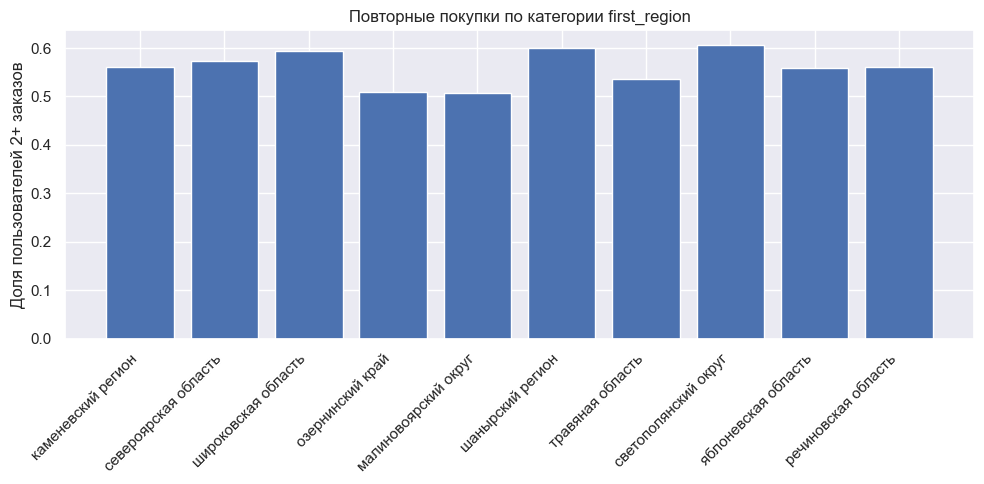

In [65]:
region_repeat = segment_return_rate_2(user_profile, "first_region")

Нельзя сделать статисиечские вывода для регионов, число заказов в которых менее половины процента от общего объема данных. Если исключить из анализа эти регоны, то данные распределены равномерно. Регион не влияет на долю возвратов.  

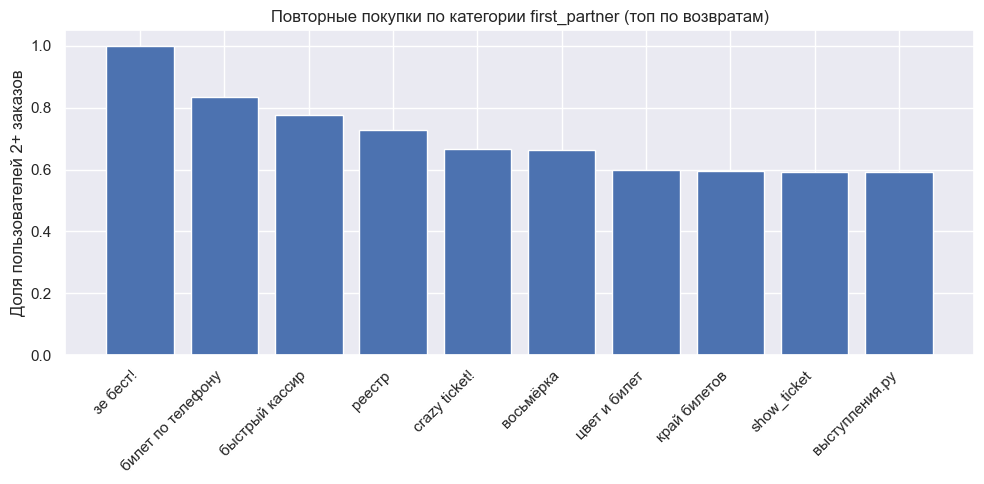

In [66]:
partner_repeat = segment_return_rate(user_profile, "first_partner")

In [67]:
first_partner_to_check = [
    "зе бест!",
    "билет по телефону",
    "быстрый кассир",
    "реестр"
]

total_users = len(user_profile)

first_partner_share_overall = (user_profile[user_profile["first_partner"].isin(regions_to_check)]["first_partner"]
    .value_counts().to_frame("count")
)

first_partner_share_overall["share"] = first_partner_share_overall["count"] / total_users 

region_share_overall

,count,share
first_region,,
озернопольская область,21,0.001135
радужнопольский край,19,0.001027
верхозёрский край,1,0.000054


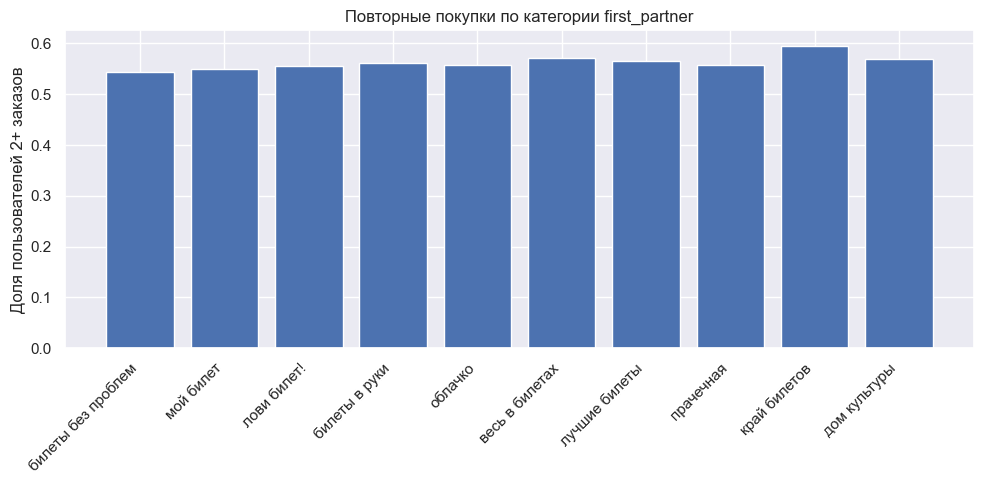

In [68]:
partner_repeat = segment_return_rate_2(user_profile, "first_partner")

Аналогчно и здесь: доля возвратов не зависиит от билетного оператора. 

#### Проверка гипотез

Гипотеза 1. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.


Гипотеза 1 не подтверждается.
Пользователи, начавшие покупать билеты со спортивных мероприятий, не совершали повторные покупки заметно чаще остальных пользователей. Различия между жанрами очень небольшие.
Повторные покупки для всех типов мероприятий находятся примерно в одном диапазоне — около 0.55–0.65.

Гипотеза 2. В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Гипотеза 2 тоже не подтверждается. Нет статистически значимых различий между регионами. 

### Исследование поведения пользователей через показатели выручки и состава заказа

#### Связь между средней выручкой сервиса с заказа и повторными заказами.

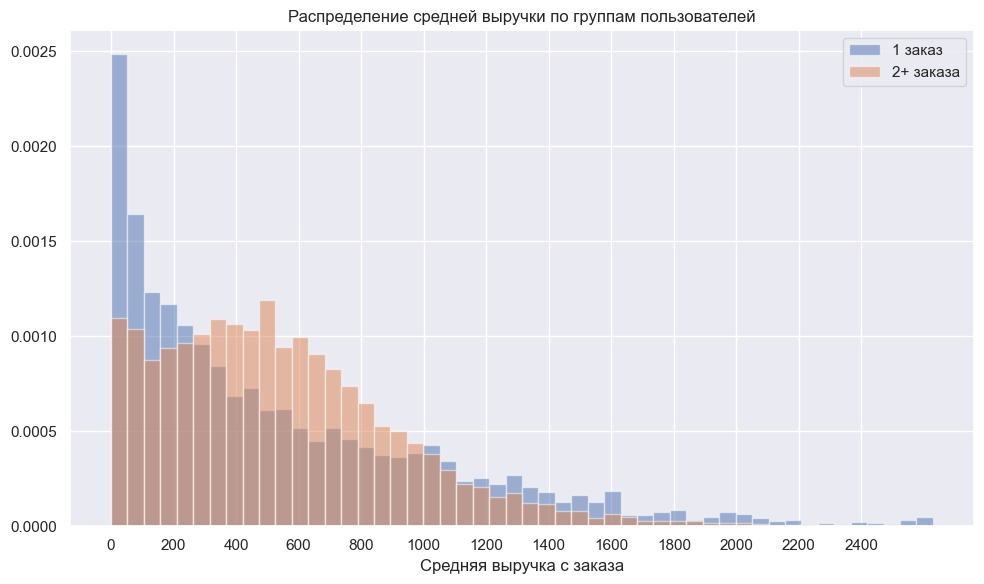

In [69]:
one_order = user_profile[user_profile['is_two'] == 0]['avg_revenue_rub']
two_order = user_profile[user_profile['is_two'] == 1]['avg_revenue_rub']

plt.figure(figsize=(10, 6))
bins = 50
plt.hist(one_order, bins=bins, density=True, alpha=0.5, label='1 заказ')
plt.hist(two_order, bins=bins, density=True, alpha=0.5, label='2+ заказа')
plt.xticks(range(0, 2501, 200))
plt.xlabel('Средняя выручка с заказа')
plt.title('Распределение средней выручки по группам пользователей')
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
one_median = round(one_order.median())
one_mean = round(one_order.mean())

two_median = round(two_order.median())
two_mean = round(two_order.mean())

print("Медиана средней выручки (1 заказ):", one_median)
print("Медиана средней выручки (2+ заказов):", two_median)
print("Среднее арифметическое средней выручки (1 заказ):", one_mean)
print("Среднее арифметическое средней выручки (2+ заказов):", two_mean)

Медиана средней выручки (1 заказ): 375
Медиана средней выручки (2+ заказов): 492
Среднее арифметическое средней выручки (1 заказ): 542
Среднее арифметическое средней выручки (2+ заказов): 544


Пользователи с 1 заказам концентрируются на очень низких значения выручки. Пик плотности в диапазоне от 0 до 100 рублей. После 300 рублей резкое снижение. Медиана равна 374 рубля

Пользователи с 2+ заказами сконцентрированы в диапазоне 0 до 800 рублей. Правый хвост менее тяжелый, чем у пользователей с 1 заказом. Медиана 491 рубль

Между распределениями есть разница. Однократные пользователи преимущественно совершают дешёвые заказы.
Их распределение концентрируется у очень малых значений. Вернувшиеся пользователи имеют более высокую среднюю выручку, их основные значения лежат в диапазоне 0-800 руб


#### Сравнение распределений по средней выручке с заказа в двух группах пользователей: 2–4 заказа и 5+ заказов

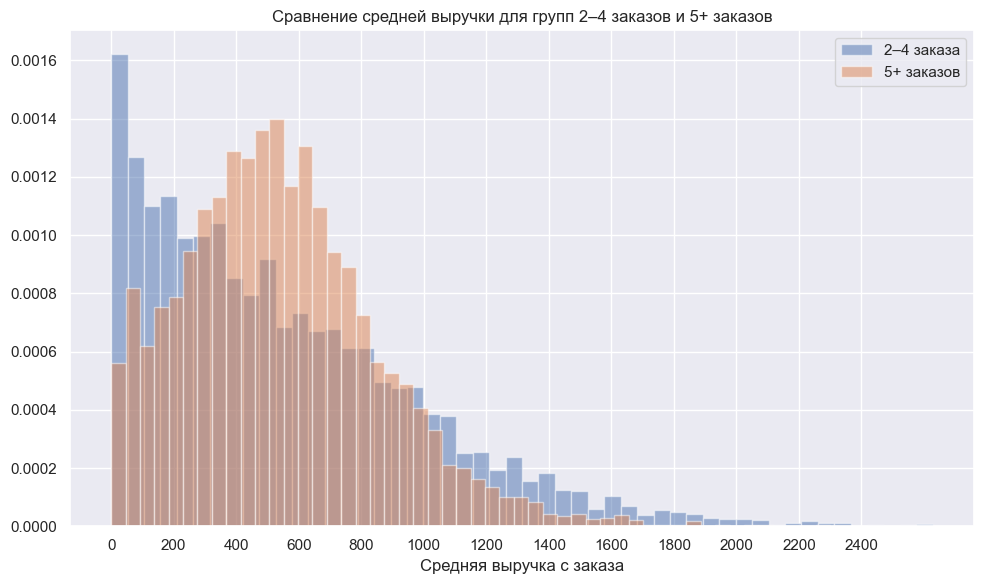

In [71]:
# пользователи с 2–4 заказами
group_A = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]['avg_revenue_rub']

# пользователи с 5+ заказами
group_B = user_profile[user_profile['total_orders'] >= 5]['avg_revenue_rub']

plt.figure(figsize=(10, 6))

bins = 50  

plt.hist(group_A, bins=bins, density=True, alpha=0.5, label='2–4 заказа')
plt.hist(group_B, bins=bins, density=True, alpha=0.5, label='5+ заказов')
plt.xticks(range(0, 2501, 200))
plt.xlabel('Средняя выручка с заказа')
plt.title('Сравнение средней выручки для групп 2–4 заказов и 5+ заказов')
plt.legend()
plt.tight_layout()
plt.show()

Распределения двух групп заметно отличаются.
Пользователи с 1 заказом в основном совершают дешёвые покупки, тогда как вернувшиеся пользователи тратят больше.

1. Общие различия
- Однократные пользователи концентрируются на очень низкой выручке.
- Пользователи с 2+ заказами имеют более высокие траты и ровное распределение.

2. Диапазоны
- 1 заказ: пик в диапазоне 0–100 руб, резкое падение после 300 руб.
- 2+ заказов: основная масса значений — 0–800 руб.

3. Медианы  и среднение 
- 1 заказ: 374 руб медиана и 542 рубля среднее. Силльное смещение вправо
- 2+ заказов: 491 руб медиана и 544 рубля среднее. Тоже сильное смещение вправо

4. Возможные причины
- Нулевая/низкая выручка у однократных — вероятно, отмены или покупка самых дешёвых билетов.
- Более высокая выручка у возвращающихся — признак большей вовлечённости и интереса к мероприятиям.

#### Влияние среднего количества билетов в заказе на вероятность повторной покупки.

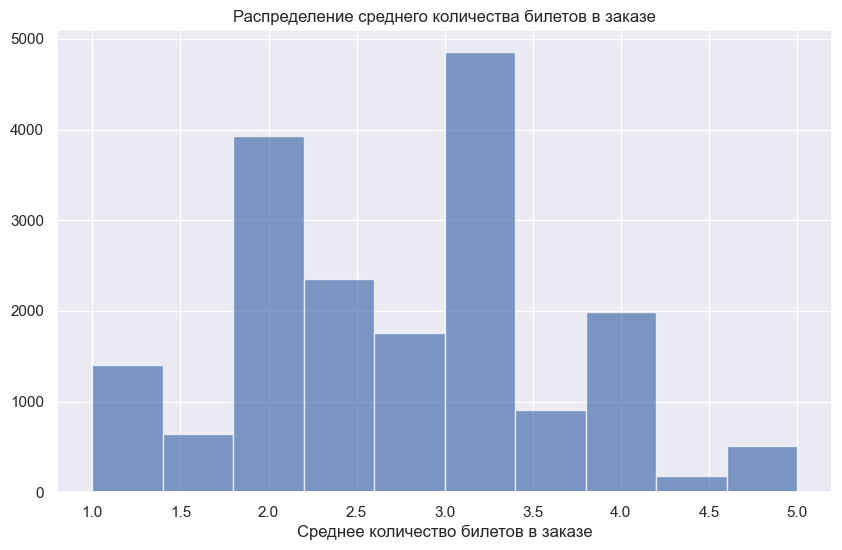

In [72]:
plt.figure(figsize=(10, 6))
plt.hist(user_profile["avg_tickets"], bins=10, alpha=0.7)
plt.xlabel("Среднее количество билетов в заказе")
plt.title("Распределение среднего количества билетов в заказе")
plt.show()

Большинство пользователей в среднем покупают 1–3 билета за заказ, реже 4. Покупки более 4 билетов встречаются значительно реже.

In [73]:
def segment_tickets(x):
    if 1 <= x < 2:
        return "1–2 билета"
    elif 2 <= x < 3:
        return "2–3 билета"
    elif 3 <= x < 5:
        return "3–5 билетов"
    else:
        return "5+ билетов"

user_profile["tickets_segment"] = user_profile["avg_tickets"].apply(segment_tickets)

In [74]:
tickets_analysis = (user_profile.groupby("tickets_segment").agg(users_count=("user_id", "count"),
return_rate=("is_two", "mean")).reset_index())

tickets_analysis

,tickets_segment,users_count,return_rate
0,1–2 билета,2202,0.466394
1,2–3 билета,7866,0.681159
2,3–5 билетов,7971,0.479865
3,5+ билетов,462,0.116883


In [75]:
user_profile[user_profile['tickets_segment'] == "5+ билетов"].head(15)

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_partner,first_event_genre,total_orders,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five,tickets_segment
20,00377cfae7548b7,2024-10-22,2024-10-22,mobile,речиновская область,мой билет,другое,1,1043.460,5.0,NaN,0,0,5+ билетов
50,00a8ab8e1de11ce,2024-10-26,2024-10-26,mobile,каменевский регион,билеты без проблем,концерты,1,1606.500,5.0,NaN,0,0,5+ билетов
132,018f325263264b1,2024-10-23,2024-10-23,mobile,солнечнореченская область,лучшие билеты,концерты,1,42.510,5.0,NaN,0,0,5+ билетов
139,01a09b1326f461e,2024-07-06,2024-07-06,mobile,широковская область,лови билет!,другое,1,391.550,5.0,NaN,0,0,5+ билетов
184,02349f76109cfd6,2024-09-27,2024-09-27,mobile,североярская область,лучшие билеты,другое,1,167.390,5.0,NaN,0,0,5+ билетов
197,026902050e7fcde,2024-09-03,2024-09-03,mobile,медовская область,билеты в руки,спорт,1,176.900,5.0,NaN,0,0,5+ билетов
212,02932d2618d2d27,2024-08-08,2024-08-08,mobile,каменевский регион,лови билет!,другое,1,265.270,5.0,NaN,0,0,5+ билетов
215,029a4864d2f52fb,2024-09-28,2024-09-28,mobile,лугоградская область,билеты без проблем,театр,1,286.930,5.0,NaN,0,0,5+ билетов
244,030314c8e81d749,2024-10-20,2024-10-20,mobile,малиновая область,лови билет!,спорт,1,230.470,5.0,NaN,0,0,5+ билетов
249,0311e5b853d6672,2024-09-06,2024-09-06,desktop,озернинский край,облачко,стендап,1,1364.210,5.0,NaN,0,0,5+ билетов


Высокая доля возвратов среди сегмента 2–3 билета. Она составляет 68%. Доля возвартов в сегменте 5+ билетов аномально низкая - всего 11%. В остальных сегментах доля возвартов около 47%

### Исследование временных характеристик первого заказа и их влияния на повторные покупки

####  Влияние дня недели, в который была совершена первая покупка, на поведение пользователей.


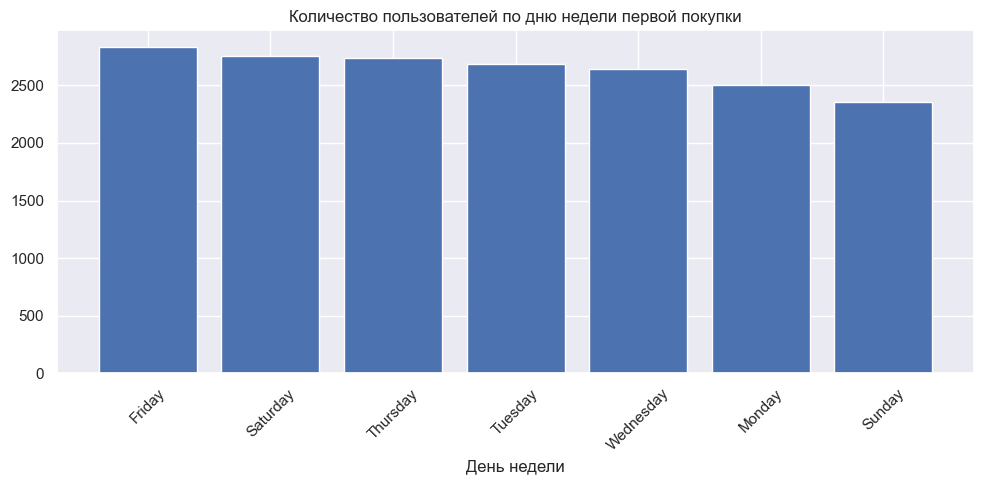

In [76]:
user_profile['first_weekday'] = user_profile['first_order_dt'].dt.day_name()

weekday_stats = (user_profile.groupby('first_weekday').agg(users_count=('user_id', 'count'),
return_rate=('is_two', 'mean')).reset_index())

# сортировка по количеству пользователей (по убыванию)
weekday_stats = weekday_stats.sort_values('users_count', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(weekday_stats['first_weekday'], weekday_stats['users_count'])
plt.title("Количество пользователей по дню недели первой покупки")
plt.xlabel("День недели")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

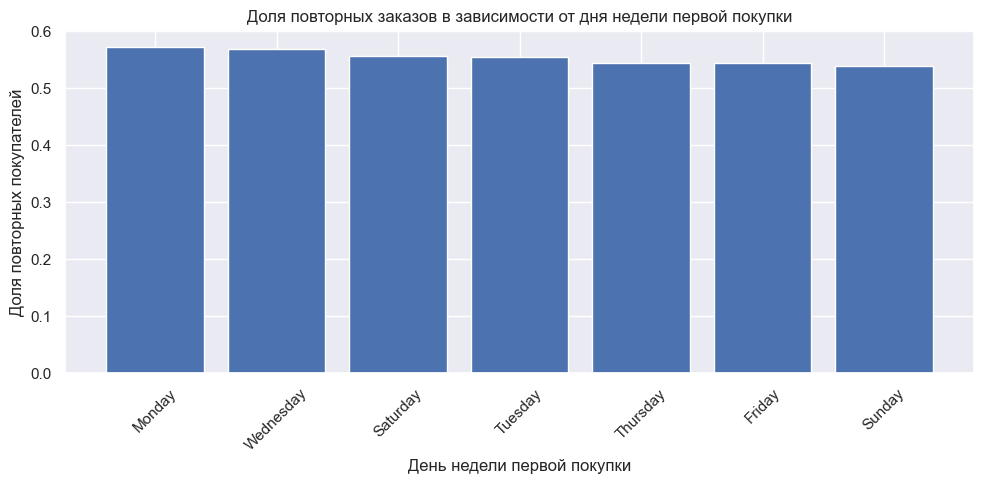

In [77]:
# сортируем по доле возвратов
weekday_sorted_rr = weekday_stats.sort_values('return_rate', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(weekday_sorted_rr['first_weekday'], weekday_sorted_rr['return_rate'])
plt.title("Доля повторных заказов в зависимости от дня недели первой покупки")
plt.ylabel("Доля повторных покупателей")
plt.xlabel("День недели первой покупки")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Доля возвратов распределена равномерно по дням недели. День недели, в которую совершена первая покупка, не влияет на вероятность возврата клиента

#### Влияние среднего интервала между заказами на удержание клиентов.

In [78]:
group_A = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)
]['avg_days_between']

group_B = user_profile[user_profile['total_orders'] >= 5]['avg_days_between']

In [79]:
mean_A = round(group_A.mean())
mean_B = round(group_B.mean())

print("Средний интервал для 2–4 заказов:", mean_A)
print("Средний интервал для 5+ заказов:", mean_B)

Средний интервал для 2–4 заказов: 7
Средний интервал для 5+ заказов: 11


Пользователи, совершившие 5 и более заказов, имеют более длинный средний интервал между покупками (11 дней), чем пользователи с 2–4 заказами (7 дней).

То есть активные и лояльные пользователи не обязательно покупают чаще: наоборот, они могут делать покупки в среднем чуть реже, но на протяжении более длительного периода времени.

###  Корреляционный анализ количества покупок и признаков пользователя

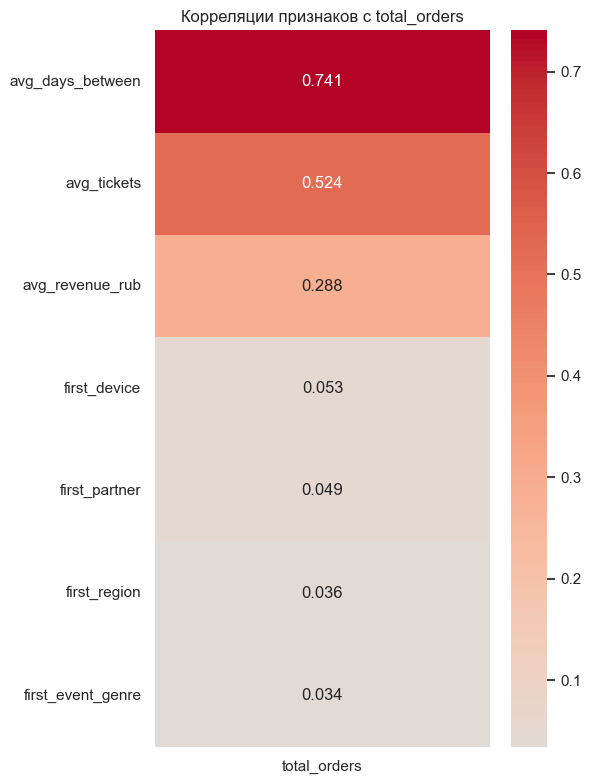

In [80]:
temp_df = user_profile[[
    'first_device',
    'first_region',
    'first_partner',
    'first_event_genre',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between',
    'total_orders'
]]

interval_cols = ['avg_revenue_rub', 'avg_tickets', 'avg_days_between', 'total_orders']

correlation_matrix = temp_df.phik_matrix(interval_cols=interval_cols)

orders_correlations = (correlation_matrix[['total_orders']].sort_values('total_orders', ascending=False).iloc[1:]   )


plt.figure(figsize=(6, 8))
sns.heatmap(orders_correlations, annot=True,fmt='.3f',cmap='coolwarm',center=0)
plt.title('Корреляции признаков с total_orders')
plt.tight_layout()
plt.show()

In [81]:
def segment_orders(x):
    if x == 1:
        return "1 заказ"
    elif 2 <= x <= 4:
        return "2–4 заказа"
    else:
        return "5+ заказов"

user_profile["orders_segment"] = user_profile["total_orders"].apply(segment_orders)

In [82]:
features = [
    'first_device',
    'first_region',
    'first_partner',
    'first_event_genre',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between',
    'total_orders'
]

In [83]:
def plot_segment_corr(df_segment, segment_name):

    temp_df = df_segment[features]
    
    corr_matrix = temp_df.phik_matrix(interval_cols=interval_cols)
    
    corr_orders = (corr_matrix[['total_orders']].sort_values('total_orders', ascending=False).iloc[1:])
    
    plt.figure(figsize=(6, 8))
    sns.heatmap(corr_orders,annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title(f"Корреляции признаков с total_orders ({segment_name})")
    plt.tight_layout()
    plt.show()

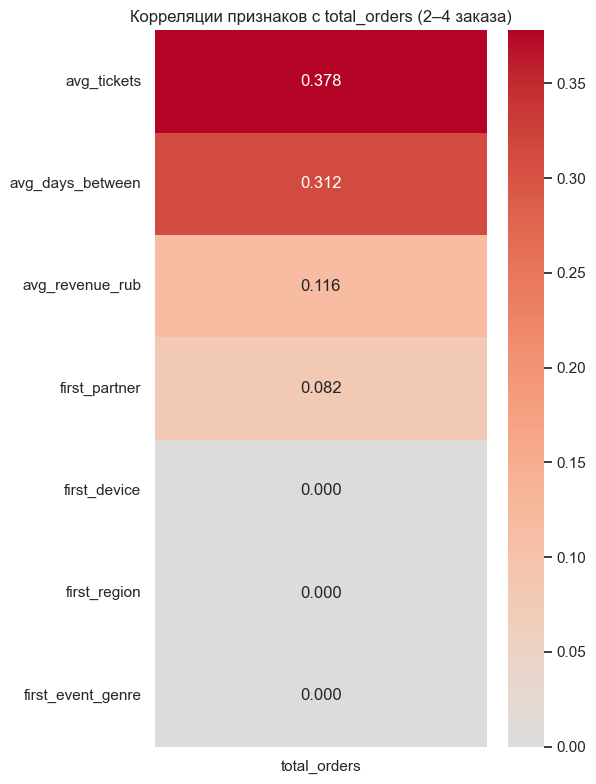

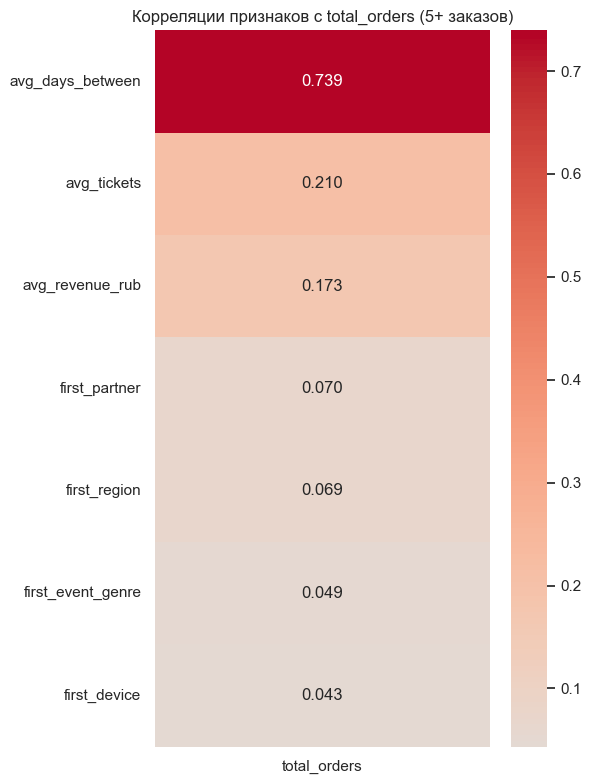

In [84]:
plot_segment_corr(user_profile[user_profile['orders_segment'] == "2–4 заказа"],"2–4 заказа")

plot_segment_corr(user_profile[user_profile['orders_segment'] == "5+ заказов"],"5+ заказов")

На количество заказов статистически значимо влияют 3 фичи: avg_days_between, avg_tickets и avg_revenue_rub. Корреляции (без сегментации по числу заказов) равны 0.74, 0.52 и 0.29 соответственно

Корреляция характеристик первого заказа (тип устройства, жанр мероприятия, регион, билетный оператор)  близки к нулю, что говорит об отсутствии связи между характеристиками первого заказа и дальнейшей активностью пользователя.

Получается, что поведенческие метрики, а не свойства первого заказа, оказывают влияние на то, сколько заказов в итоге совершит пользователь.

### Промежуточные выводы
В результате исследовательского анализа данных было выяснено, что 
- Характеристики первого заказа (жанр, девайс, регион и билетный парнтнер) не влияют на то, продолжит ли клиент пользоваться сервисом 
- Пользователи с 1 заказом чаще всего имеют очень низкую среднюю выручку: пик до 100 руб, резкий спад после 300 руб, медиана — 374 руб. У пользователей с 2+ заказами распределение шире (до 800 руб), хвост более лёгкий, медиана выше — 491 руб.
- У пользователей с 5+ заказами средняя выручка заметно выше: распределение смещено вправо, пик — 400–700 руб,  группы с 2–4 заказами пик расположен гораздо левее — 150–350 руб. Чем выше средняя выручка, тем выше вероятность, что пользователь является лояльным (5+ заказов).
- Сегмент пользователей, покупающих 2–3 билета, демонстрирует самую высокую долю возвратов — 68%.
Доля возвратов в группе 5+ билетов аномально низкая — всего 11%. В остальных сегментах показатель около 47%.
- У пользователей с 5+ заказами средний интервал между покупками  — около 11 дней, тогда как у группы 2–4 заказов — около 7 дней. Это означает, что лояльные пользователи совершают покупки не чаще, а более равномерно и долгое время.
- На число заказов влияют только поведенческие признаки(в скобках указана корреляция phik с числом заказов): avg_days_between (0.74), avg_tickets (0.52) и avg_revenue_rub (0.29). Параметры первого заказа (устройство, жанр, регион, партнёр) почти не связаны с дальнейшей активностью.

## Итоговый вывод и рекомендации 

В анализе использованы 290 611 заказов Яндекс Афиши.
Данные очищены от выбросов, приведены к корректным типам. выручка конвертирована в рубли. Пропуски встречаются только в days_since_prev — у пользователей с 1 заказом. После подготовки данные сократились примерно на 1%.

Построен профиль пользователей. Обработан от выбросов для большей репрезентативности. В результаты обработки датасет скоращен на 14%. 

Основные результаты анализа профиля пользователей: 

Характеристики первого заказа (жанр, девайс, регион, билетный оператор) не связаны с возвратами.

Лояльность определяется поведением, а не первым заказом:
- пользователи с 1 заказом имеют низкую среднюю выручку (медиана ~374 руб),
- у пользователей с 2+ заказами распределение шире и медиана выше (~491 руб),
- у сегмента 5+ заказов выручка ещё выше (пик 400–700 руб).

По числу билетов лучший сегмент — 2–3 билета (возвраты ~68%).
Сегмент 5+ билетов возвращается редко (~11%), так как это часто разовые групповые покупки.

Интервалы между покупками у лояльных пользователей длиннее:
~7 дней (2–4 заказа) против ~11 дней (5+ заказов).
То есть лояльность — это регулярность во времени, а не частота.

Корреляции с количеством заказов значимы только у поведенческих признаков:
- avg_days_between — 0.74
- avg_tickets — 0.52
- avg_revenue_rub — 0.29
Признаки первого заказа почти не влияют.

Рекомендации
1. Использовать поведенческую сегментацию (средняя выручка, число билетов, интервалы) для персональных предложений и триггерных рассылок.
2. Фокус на пользователях с высокой средней выручкой: предлагать им ранний доступ, подборки более дорогих событий и бонусные программы — это наиболее лояльная аудитория.
3. Развивать сегмент “2–3 билета” — лучший по возвратам. Предлагать скидки при покупке 2+ билетов, подборки событий для пары/небольшой компании, акции «купи два — получи скидку на третье».
4. Для сегмента 5+ билетов использовать отдельные кампании: корпоративные пакеты, групповые скидки, предложения для школ, вузов, тургрупп.
5. Запустить триггерные рассылки по времени (7–14 дней после покупки), так как лояльные пользователи покупают регулярно, но с более длинными интервалами.
6. Работать с однократными пользователями: предлагать промокоды на второй заказ, бюджетные подборки
7. Использовать avg_revenue_rub как ключевой индикатор лояльности, так как более высокая средняя выручка напрямую связана с большей вероятностью повторных покупок.
